In [1]:
# --- 1. KESKKONNA SEADISTAMINE ---
!git clone https://github.com/wazenmai/MIDI-BERT.git
%cd MIDI-BERT

!pip install miditoolkit==0.1.14 mido==1.2.10 numpy transformers seaborn matplotlib scikit-learn pandas tqdm music21

import sys
import os

if os.path.basename(os.getcwd()) != "MIDI-BERT":
    %cd MIDI-BERT
sys.path.append(os.getcwd())

!mkdir -p Data/CP_data/tmp
!mkdir -p data_creation/prepare_data/dict
!python data_creation/prepare_data/dict/make_dict.py

if os.path.exists('data_creation/prepare_data/dict/CP.pkl'):
    print("EDUKAS: Sõnastik CP.pkl on loodud!")
else:
    print("VIGA: Sõnastikku ei tekkinud.")

Cloning into 'MIDI-BERT'...
remote: Enumerating objects: 1258, done.
remote: Counting objects: 100% (392/392), done.
remote: Compressing objects: 100% (254/254), done.
remote: Total 1258 (delta 171), reused 344 (delta 134), pack-reused 866 (from 1)
Receiving objects: 100% (1258/1258), 125.78 MiB | 5.46 MiB/s, done.
Resolving deltas: 100% (619/619), done.
Updating files: 100% (164/164), done.
/content/MIDI-BERT
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.7 MB/s eta 0:00:00
  Created wheel for miditoolkit: filename=miditoolkit-0.1.14-py3-none-any.whl size=19508 sha256=9a66d2916bdaa4a82e5f997ef913ffef770af88cd27eb3badfc6122c9848c5a4
  Stored in directory: /root/.cache/pip/wheels/f0/6e/d3/005b67a60d4a610bc9de6a19f02d205e7ce19972725138fff4
Successfully built miditoolkit
{'Bar': {'Bar New': 0, 'Bar Continue': 1, 'Bar <PAD>': 2, 'Bar <MASK>': 3}, 'Position': {'Position 1/16': 0, 'Position 2/16': 1, 'Position 3/16': 2, 'Position 4/16': 3,

In [2]:
# --- 2. MUDELI LAADIMINE JA ARHITEKTUUR ---
from google.colab import drive
import torch
import torch.nn as nn
import pickle
import numpy as np
from transformers import BertConfig
from data_creation.prepare_data.model import CP
from MidiBERT.model import MidiBert

np.int = int
drive.mount('/content/drive')

ckpt_path = '/content/drive/MyDrive/LÕPUTÖÖ/MidiBERT-Piano/CP/pretrain_model.ckpt'
dict_path = 'data_creation/prepare_data/dict/CP.pkl'

with open(dict_path, 'rb') as f:
    e2w, w2e = pickle.load(f)

config = BertConfig(
    max_position_embeddings=512,
    position_embedding_type='relative_key_query',
    hidden_size=768, num_attention_heads=12, num_hidden_layers=12,
    pad_token_id=0, output_attentions=True, attn_implementation="eager"
)
config._attn_implementation = "eager"

midibert_base = MidiBert(bertConfig=config, e2w=e2w, w2e=w2e)
print("Laen eeltreenitud kaalusid...")
checkpoint = torch.load(ckpt_path, map_location='cpu')
state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
clean_state_dict = {k.replace("module.", "").replace("midibert.", ""): v for k, v in state_dict.items()}
midibert_base.load_state_dict(clean_state_dict, strict=False)
print("EDUKAS: Eeltreenitud MidiBERT on valmis!")

cp_model = CP(dict=dict_path)


class FolkClassifier(nn.Module):
    """
    UUS:
    - MASKED POOLING: padding-tokeneid ei keskmistata
    - Dropout 0.5 (oli 0.3) - ülesobitamise vastu
    - mask_bar_tokens optsioon ablatsiooni-eksperimendiks
    """
    def __init__(self, pretrained_midibert, num_classes, mask_bar_tokens=False):
        super().__init__()
        self.midibert = pretrained_midibert
        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(768, num_classes)
        self.mask_bar_tokens = mask_bar_tokens

    def forward(self, input_ids, attn_mask, return_attentions=False):
        if self.mask_bar_tokens:
            input_ids = input_ids.clone()
            input_ids[..., 0] = 0  # Bar-info maskimine

        embs = [self.midibert.word_emb[i](input_ids[..., i])
                for i, _ in enumerate(self.midibert.classes)]
        emb_linear = self.midibert.in_linear(torch.cat([*embs], dim=-1))

        outputs = self.midibert.bert(
            inputs_embeds=emb_linear, attention_mask=attn_mask,
            output_hidden_states=True, output_attentions=True
        )

        # MASKED POOLING — keskmista AINULT mitte-padding tokenid
        hidden = outputs.last_hidden_state
        mask = attn_mask.unsqueeze(-1).float()
        summed = (hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)
        pooled_output = summed / counts

        logits = self.classifier(self.dropout(pooled_output))
        if return_attentions:
            return logits, outputs.attentions
        return logits

target_labels = ['Eesti', 'Soome']
label_to_id = {name: i for i, name in enumerate(target_labels)}

Mounted at /content/drive
Laen eeltreenitud kaalusid...
EDUKAS: Eeltreenitud MidiBERT on valmis!


In [ ]:
# --- 2.5. PIPELINE: ÜHESAMMULINE konversioon, tempo-norm ---
import music21 as m21
import miditoolkit
import os, glob, shutil, random
from tqdm import tqdm

estonian_dir = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/eesti"
finnish_dir = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/soome"
output_dir = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/processed"
os.makedirs(os.path.join(output_dir, "eesti"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "soome"), exist_ok=True)


def convert_xml_to_midi(xml_path, midi_path):
    """ÜKS samm: XML → MIDI. Time signature säilitamine kindlustatud."""
    try:
        score = m21.converter.parse(xml_path)
        score.write('midi', fp=midi_path)
        # Kontroll: kui time signature kadus, lisame käsitsi
        midi = miditoolkit.MidiFile(midi_path)
        if not midi.time_signature_changes:
            time_sigs = score.recurse().getElementsByClass('TimeSignature')
            if time_sigs:
                ts = time_sigs[0]
                midi.time_signature_changes = [
                    miditoolkit.TimeSignature(numerator=ts.numerator,
                                              denominator=ts.denominator, time=0)
                ]
                midi.dump(midi_path)
        return True
    except Exception as e:
        print(f"  [VIGA] {os.path.basename(xml_path)}: {e}")
        return False


def normalize_tempo(midi_path, target_tempo=120):
    """Eemaldab tempo-leak'i: kõik failid 120 BPM-i."""
    try:
        midi = miditoolkit.MidiFile(midi_path)
        midi.tempo_changes = [miditoolkit.TempoChange(tempo=target_tempo, time=0)]
        midi.dump(midi_path)
        return True
    except Exception as e:
        return False


# --- EESTI: XML/MIDI → puhas MIDI ---
estonian_files = (glob.glob(os.path.join(estonian_dir, "**", "*.xml"), recursive=True) +
                  glob.glob(os.path.join(estonian_dir, "**", "*.mxl"), recursive=True) +
                  glob.glob(os.path.join(estonian_dir, "**", "*.musicxml"), recursive=True) +
                  glob.glob(os.path.join(estonian_dir, "**", "*.mid"), recursive=True) +
                  glob.glob(os.path.join(estonian_dir, "**", "*.midi"), recursive=True))
print(f"Eesti faile leitud: {len(estonian_files)}")

success_e = 0
for f in tqdm(estonian_files, desc="Eesti pipeline"):
    name = os.path.splitext(os.path.basename(f))[0] + ".mid"
    out = os.path.join(output_dir, "eesti", name)
    if f.lower().endswith(('.mid', '.midi')):
        shutil.copy(f, out)
        ok = True
    else:
        ok = convert_xml_to_midi(f, out)
    if ok and normalize_tempo(out):
        success_e += 1

# --- SOOME: kopeerime + tempo-norm ---
finnish_files = (glob.glob(os.path.join(finnish_dir, "**", "*.mid"), recursive=True) +
                 glob.glob(os.path.join(finnish_dir, "**", "*.midi"), recursive=True))
print(f"\nSoome faile leitud: {len(finnish_files)}")

success_f = 0
for f in tqdm(finnish_files, desc="Soome pipeline"):
    name = os.path.splitext(os.path.basename(f))[0] + ".mid"
    out = os.path.join(output_dir, "soome", name)
    shutil.copy(f, out)
    if normalize_tempo(out):
        success_f += 1

print(f"\nVALMIS! Eesti: {success_e}/{len(estonian_files)}, Soome: {success_f}/{len(finnish_files)}")

# DIAGNOSTIKA: kas time signature ja struktuur sobib?
print("\n=== DIAGNOSTIKA (paari faili statistika) ===")
random.seed(42)
sample_e = random.sample(glob.glob(os.path.join(output_dir, "eesti", "*.mid")),
                         min(3, len(glob.glob(os.path.join(output_dir, "eesti", "*.mid")))))
sample_f = random.sample(glob.glob(os.path.join(output_dir, "soome", "*.mid")), 3)
for label, files in [("EESTI", sample_e), ("SOOME", sample_f)]:
    print(f"\n--- {label} näidised ---")
    for f in files:
        midi = miditoolkit.MidiFile(f)
        n_notes = sum(len(inst.notes) for inst in midi.instruments)
        ts = midi.time_signature_changes
        ts_str = f"{ts[0].numerator}/{ts[0].denominator}" if ts else "PUUDUB"
        tempo = midi.tempo_changes[0].tempo if midi.tempo_changes else "PUUDUB"
        print(f"  {os.path.basename(f)}: {n_notes} nooti, takt {ts_str}, tempo {tempo}")

Eesti faile leitud: 77


Eesti pipeline:   5%|▌         | 4/77 [00:02<00:42,  1.72it/s]

  [VIGA] 17.xml: cannot expand Stream: badly formed repeats or repeat expressions


Eesti pipeline:  10%|█         | 8/77 [00:04<00:38,  1.81it/s]

  [VIGA] 14.xml: cannot expand Stream: badly formed repeats or repeat expressions


...

  [VIGA] 25.xml: cannot expand Stream: badly formed repeats or repeat expressions


Eesti pipeline: 100%|██████████| 77/77 [00:44<00:00,  1.72it/s]



Soome faile leitud: 702


Soome pipeline: 100%|██████████| 702/702 [00:34<00:00, 20.30it/s]


VALMIS! Eesti: 60/77, Soome: 702/702

=== DIAGNOSTIKA (paari faili statistika) ===

--- EESTI näidised ---
  30.mid: 118 nooti, takt 4/4, tempo 120.0
  9.mid: 114 nooti, takt 2/4, tempo 120.0
  5.mid: 95 nooti, takt 4/4, tempo 120.0

--- SOOME näidised ---
  kt1_0393.mid: 58 nooti, takt 2/4, tempo 120.0
  kt1_0421.mid: 58 nooti, takt 2/4, tempo 120.0
  kt1_0335.mid: 47 nooti, takt 2/4, tempo 120.0


In [ ]:
# --- 2.6. PARANDA EBAÕNNESTUNUD EESTI FAILID ---
# Eemaldame kordusmärgid enne MIDI-kirjutamist, sest just need põhjustasid vea.

import music21 as m21
from music21 import bar
import os, glob
from tqdm import tqdm

estonian_src = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/eesti"
estonian_out = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/processed/eesti"

# Leia XML-failid, mida pole veel MIDI-na processed/-kaustas
all_xml = (glob.glob(os.path.join(estonian_src, "**", "*.xml"), recursive=True) +
           glob.glob(os.path.join(estonian_src, "**", "*.mxl"), recursive=True) +
           glob.glob(os.path.join(estonian_src, "**", "*.musicxml"), recursive=True))

processed_names = {os.path.splitext(os.path.basename(f))[0]
                   for f in glob.glob(os.path.join(estonian_out, "*.mid"))}
missing = [f for f in all_xml
           if os.path.splitext(os.path.basename(f))[0] not in processed_names]
print(f"Puuduvaid Eesti faile: {len(missing)}")


def convert_with_repeat_strip(xml_path, midi_path):
    """Eemaldab kordusmärkused enne MIDI-kirjutamist."""
    try:
        score = m21.converter.parse(xml_path)

        # Eemaldame voltas (1st ending, 2nd ending)
        for rb in list(score.recurse().getElementsByClass('RepeatBracket')):
            try:
                rb.activeSite.remove(rb)
            except:
                pass

        # Eemaldame repeat-barlines (asendame tavaliste barlinedega)
        for measure in score.recurse().getElementsByClass('Measure'):
            for bl in list(measure.getElementsByClass(bar.Repeat)):
                try:
                    measure.remove(bl)
                except:
                    pass
            # Asendame leftBarline ja rightBarline kui need on Repeat
            if isinstance(measure.leftBarline, bar.Repeat):
                measure.leftBarline = bar.Barline('regular')
            if isinstance(measure.rightBarline, bar.Repeat):
                measure.rightBarline = bar.Barline('regular')

        # Eemaldame DC, DS, Coda, Segno markused
        for el in list(score.recurse().getElementsByClass(
                ['RepeatExpression', 'DalSegno', 'DaCapo', 'Coda', 'Segno'])):
            try:
                el.activeSite.remove(el)
            except:
                pass

        score.write('midi', fp=midi_path)
        return True
    except Exception as e:
        print(f"  [IKKAGI VIGA] {os.path.basename(xml_path)}: {e}")
        return False


# Käivitame ja salvestame
import miditoolkit

def normalize_tempo(midi_path, target_tempo=120):
    try:
        midi = miditoolkit.MidiFile(midi_path)
        midi.tempo_changes = [miditoolkit.TempoChange(tempo=target_tempo, time=0)]
        midi.dump(midi_path)
        return True
    except:
        return False


fixed = 0
for f in tqdm(missing, desc="Parandan repeat-vigu"):
    name = os.path.splitext(os.path.basename(f))[0] + ".mid"
    out = os.path.join(estonian_out, name)
    if convert_with_repeat_strip(f, out):
        normalize_tempo(out)
        fixed += 1

print(f"\nParandatud: {fixed}/{len(missing)}")

# Lõplik kokkuvõte
total_e = len(glob.glob(os.path.join(estonian_out, "*.mid")))
total_s = len(glob.glob("/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/processed/soome/*.mid"))
print(f"\nLõplik andmestik: Eesti {total_e}/77, Soome {total_s}/702")

Puuduvaid Eesti faile: 17


Parandan repeat-vigu: 100%|██████████| 17/17 [00:01<00:00,  9.36it/s]


Parandatud: 17/17

Lõplik andmestik: Eesti 77/77, Soome 702/702


In [ ]:
# --- 2.7. ÜHTLUSTA TICKS_PER_BEAT KÕIGIL FAILIDEL ---
# Probleem: music21 kirjutab MIDI-d 10080 tpb-ga, soome failid on 256.
# CP tokenizer ei suuda nii kõrge resolutsiooniga taktipiire õigesti tuvastada.
# Lahendus: kõigile 480 (standard MIDI-tarkvara väärtus, sobib hästi 16-osa positsioonidega).

import miditoolkit
from copy import deepcopy
import glob, os
from tqdm import tqdm

TARGET_TPB = 480

def resample_ticks_per_beat(midi_path, target_tpb=TARGET_TPB):
    """Skaleerib kõik tick-väärtused MIDI-failis nii, et ticks_per_beat = target_tpb."""
    try:
        midi = miditoolkit.MidiFile(midi_path)
        old_tpb = midi.ticks_per_beat
        if old_tpb == target_tpb:
            return True

        scale = target_tpb / old_tpb

        # Skaleerime noodid
        for inst in midi.instruments:
            for note in inst.notes:
                note.start = int(round(note.start * scale))
                note.end = int(round(note.end * scale))
            for cc in inst.control_changes:
                cc.time = int(round(cc.time * scale))
            for pb in inst.pitch_bends:
                pb.time = int(round(pb.time * scale))

        # Skaleerime tempo-, takti- ja võtmemuudatused
        for tc in midi.tempo_changes:
            tc.time = int(round(tc.time * scale))
        for ts in midi.time_signature_changes:
            ts.time = int(round(ts.time * scale))
        for ks in midi.key_signature_changes:
            ks.time = int(round(ks.time * scale))
        for marker in midi.markers:
            marker.time = int(round(marker.time * scale))

        midi.ticks_per_beat = target_tpb
        midi.dump(midi_path)
        return True
    except Exception as e:
        print(f"  [VIGA] {os.path.basename(midi_path)}: {e}")
        return False


# Käivitame mõlema korpuse peal
processed_root = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/processed"
all_files = (glob.glob(os.path.join(processed_root, "eesti", "*.mid")) +
             glob.glob(os.path.join(processed_root, "soome", "*.mid")))

print(f"Skaleerin {len(all_files)} faili ticks_per_beat = {TARGET_TPB}...")
ok = 0
for f in tqdm(all_files):
    if resample_ticks_per_beat(f):
        ok += 1
print(f"\nValmis: {ok}/{len(all_files)}")

# Kontroll: kas ticks_per_beat on nüüd ühesugune?
print("\n=== KONTROLL ===")
import random
random.seed(0)
e_files = sorted(glob.glob(os.path.join(processed_root, "eesti", "*.mid")))
s_files = sorted(glob.glob(os.path.join(processed_root, "soome", "*.mid")))

for f in random.sample(e_files, 3):
    midi = miditoolkit.MidiFile(f)
    print(f"  EESTI {os.path.basename(f)}: tpb={midi.ticks_per_beat}")
for f in random.sample(s_files, 3):
    midi = miditoolkit.MidiFile(f)
    print(f"  SOOME {os.path.basename(f)}: tpb={midi.ticks_per_beat}")

# JOOKSUTAME UUESTI CP DIAGNOSTIKA, et näha, kas Bar-token suhe on nüüd korras
print("\n=== UUS BAR-TOKEN STATISTIKA EESTI FAILIDEL ===")
for f in random.sample(e_files, 2):
    print(f"\n--- {os.path.basename(f)} ---")
    try:
        input_ids, _ = cp_model.prepare_data([f], task='melody', max_len=256)
        seg = np.array(input_ids[0])
        non_pad = seg[seg[:, 0] != 2]
        bar_new = (non_pad[:, 0] == 0).sum()
        bar_cont = (non_pad[:, 0] == 1).sum()
        print(f"  Bar New: {bar_new}, Bar Continue: {bar_cont}, "
              f"suhe: {bar_new}:{bar_cont}")
        # Esimesed 10 tokenit
        print("  Esimesed 10:")
        for i in range(min(10, len(non_pad))):
            print(f"    {w2e['Bar'][int(non_pad[i,0])]:13s} | "
                  f"{w2e['Position'][int(non_pad[i,1])]:15s} | "
                  f"Pitch {int(non_pad[i,2])+22}")
    except Exception as e:
        print(f"  VIGA: {e}")

Skaleerin 779 faili ticks_per_beat = 480...


100%|██████████| 779/779 [00:16<00:00, 48.19it/s]



Valmis: 779/779

=== KONTROLL ===
  EESTI 54.mid: tpb=480
  EESTI 58.mid: tpb=480
  EESTI 14.mid: tpb=480
  SOOME kt1_0258.mid: tpb=480
  SOOME kt1_0500.mid: tpb=480
  SOOME kt1_0474.mid: tpb=480

=== UUS BAR-TOKEN STATISTIKA EESTI FAILIDEL ===

--- 56.mid ---


100%|██████████| 1/1 [00:00<00:00, 149.69it/s]


  Bar New: 4, Bar Continue: 49, suhe: 4:49
  Esimesed 10:
    Bar New       | Position 1/16   | Pitch 81
    Bar Continue  | Position 1/16   | Pitch 81
    Bar Continue  | Position 3/16   | Pitch 81
    Bar Continue  | Position 3/16   | Pitch 81
    Bar Continue  | Position 4/16   | Pitch 79
    Bar Continue  | Position 4/16   | Pitch 79
    Bar Continue  | Position 5/16   | Pitch 81
    Bar Continue  | Position 5/16   | Pitch 81
    Bar Continue  | Position 6/16   | Pitch 79
    Bar Continue  | Position 6/16   | Pitch 79

--- 44.mid ---


100%|██████████| 1/1 [00:00<00:00, 123.49it/s]

  Bar New: 6, Bar Continue: 76, suhe: 6:76
  Esimesed 10:
    Bar New       | Position 1/16   | Pitch 78
    Bar Continue  | Position 2/16   | Pitch 76
    Bar Continue  | Position 3/16   | Pitch 78
    Bar Continue  | Position 4/16   | Pitch 79
    Bar Continue  | Position 5/16   | Pitch 81
    Bar Continue  | Position 6/16   | Pitch 81
    Bar Continue  | Position 7/16   | Pitch 81
    Bar Continue  | Position 8/16   | Pitch 78
    Bar Continue  | Position 9/16   | Pitch 74
    Bar Continue  | Position 11/16  | Pitch 74


In [3]:
# --- 3. KÕIK PALAD KOOS (split toimub fold-i ajal) ---
import glob, os, tempfile
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from collections import defaultdict
from tqdm import tqdm
import miditoolkit

processed_root = "/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/processed"
estonian_files = sorted(glob.glob(os.path.join(processed_root, "eesti", "*.mid")))
finnish_files = sorted(glob.glob(os.path.join(processed_root, "soome", "*.mid")))
print(f"Eesti palu: {len(estonian_files)}, Soome palu: {len(finnish_files)}")

# Kogume kõik palad ühte listi: (path, label, song_id)
all_songs = []
for i, f in enumerate(estonian_files):
    all_songs.append((f, label_to_id['Eesti'], i))
for i, f in enumerate(finnish_files):
    all_songs.append((f, label_to_id['Soome'], len(estonian_files) + i))

all_paths = [s[0] for s in all_songs]
all_labels = np.array([s[1] for s in all_songs])
all_song_ids = np.array([s[2] for s in all_songs])
print(f"Kokku palu: {len(all_songs)}")
print(f"Eesti: {(all_labels == 0).sum()}, Soome: {(all_labels == 1).sum()}")


# Konstandid
MAX_LEN = 256
PADDING_THRESHOLD = 0.7
MAX_SEGMENTS_PER_FILE = 6
SHIFT_RANGE = list(range(-5, 6))


def transpose_midi_temp(midi_path, semitones):
    midi = miditoolkit.MidiFile(midi_path)
    for inst in midi.instruments:
        for note in inst.notes:
            note.pitch = max(0, min(127, note.pitch + semitones))
    tmp = tempfile.NamedTemporaryFile(suffix='.mid', delete=False)
    midi.dump(tmp.name)
    return tmp.name


def tokenize_file(midi_path, label, song_id):
    """Tagastab list (input_ids, label, song_id), filtreerib palju-padding-segmendid."""
    try:
        input_ids, _ = cp_model.prepare_data([midi_path], task='melody', max_len=MAX_LEN)
        out = []
        for i, seg in enumerate(input_ids[:MAX_SEGMENTS_PER_FILE]):
            seg_arr = np.array(seg)
            padding_ratio = (seg_arr[:, 0] == 2).mean()
            if padding_ratio < PADDING_THRESHOLD:
                out.append((seg, label, song_id))
        return out
    except Exception as e:
        return []


def build_segments(paths, labels, song_ids, augment=False):
    """Ehitab segmenteeritud andmestiku. Augment=True ainult treeningus, ainult Eesti palad."""
    np.random.seed(43)
    segments = []
    for path, label, sid in tqdm(list(zip(paths, labels, song_ids)),
                                  desc="Augment" if augment else "Plain"):
        if augment and label == label_to_id['Eesti']:
            for shift in SHIFT_RANGE:
                if shift == 0:
                    segments.extend(tokenize_file(path, label, sid))
                else:
                    tmp = transpose_midi_temp(path, shift)
                    segments.extend(tokenize_file(tmp, label, sid))
                    os.remove(tmp)
        else:
            segments.extend(tokenize_file(path, label, sid))
    return segments


class FolkDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        seg, label, song_id = self.data[idx]
        input_tensor = torch.tensor(seg, dtype=torch.long)
        attn_mask = (input_tensor[:, 0] != 2).float()
        return input_tensor, attn_mask, torch.tensor(label, dtype=torch.long), song_id


print("Andmestiku struktuur valmis. Tegelik tokeniseerimine toimub fold'is.")

Eesti palu: 77, Soome palu: 702
Kokku palu: 779
Eesti: 77, Soome: 702
Andmestiku struktuur valmis. Tegelik tokeniseerimine toimub fold'is.


In [ ]:
# --- DIAGNOSTIKA: mis CP tokenizer näeb? ---
import miditoolkit
from collections import Counter

def detailed_inspection(midi_path, label):
    """Näitame tegelikku MIDI struktuuri ja CP tokenite väljundit."""
    print(f"\n{'='*60}")
    print(f"{label}: {os.path.basename(midi_path)}")
    print('='*60)

    # 1. Toores MIDI info
    midi = miditoolkit.MidiFile(midi_path)
    n_notes = sum(len(inst.notes) for inst in midi.instruments)
    print(f"\n[MIDI TOORES]")
    print(f"  ticks_per_beat: {midi.ticks_per_beat}")
    print(f"  time_signatures: {midi.time_signature_changes}")
    print(f"  tempo_changes: {midi.tempo_changes}")
    print(f"  noote kokku: {n_notes}")
    if midi.instruments and midi.instruments[0].notes:
        notes = midi.instruments[0].notes
        max_tick = max(n.end for n in notes)
        print(f"  pala pikkus tickides: {max_tick}")
        # Kui palju takte tegelikult on?
        if midi.time_signature_changes:
            ts = midi.time_signature_changes[0]
            ticks_per_bar = midi.ticks_per_beat * 4 * ts.numerator / ts.denominator
            print(f"  ühe takti pikkus tickides: {ticks_per_bar:.0f}")
            print(f"  arvutatud taktide arv: {max_tick / ticks_per_bar:.1f}")
        # Esimesed 5 nooti
        print(f"  esimesed 5 nooti (tick, pitch):")
        for n in notes[:5]:
            print(f"    start={n.start}, end={n.end}, pitch={n.pitch}")

    # 2. CP tokenite väljund
    try:
        input_ids, _ = cp_model.prepare_data([midi_path], task='melody', max_len=256)
        print(f"\n[CP TOKENITE VÄLJUND]")
        print(f"  segmente: {len(input_ids)}")
        if len(input_ids) > 0:
            seg = np.array(input_ids[0])
            non_pad_mask = seg[:, 0] != 2
            non_pad = seg[non_pad_mask]

            bar_counts = Counter(non_pad[:, 0].tolist())
            print(f"  esimese segmendi mitte-padding tokeneid: {len(non_pad)}")
            print(f"  Bar New (kood 0): {bar_counts.get(0, 0)}")
            print(f"  Bar Continue (kood 1): {bar_counts.get(1, 0)}")

            # Esimesed 20 tokenit dekodeerituna
            print(f"\n  Esimesed 15 tokenit (Bar / Pos / Pitch / Dur):")
            for i in range(min(15, len(non_pad))):
                bar_label = w2e['Bar'][int(non_pad[i, 0])]
                pos_label = w2e['Position'][int(non_pad[i, 1])]
                pitch_label = w2e['Pitch'][int(non_pad[i, 2])]
                dur_label = w2e['Duration'][int(non_pad[i, 3])]
                print(f"    {i}: {bar_label} | {pos_label} | {pitch_label} | {dur_label}")
    except Exception as e:
        print(f"  [VIGA] {e}")


# 2 Eesti + 2 Soome
import random
random.seed(0)
e_files = sorted(glob.glob("/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/processed/eesti/*.mid"))
s_files = sorted(glob.glob("/content/drive/MyDrive/LÕPUTÖÖ/rahvalaulud/processed/soome/*.mid"))

for f in random.sample(e_files, 2):
    detailed_inspection(f, "EESTI")
for f in random.sample(s_files, 2):
    detailed_inspection(f, "SOOME")


EESTI: 54.mid

[MIDI TOORES]
  ticks_per_beat: 10080
  time_signatures: [TimeSignature(numerator=2, denominator=4, time=0)]
  tempo_changes: [TempoChange(tempo=120.0, time=0)]
  noote kokku: 122
  pala pikkus tickides: 685440
  ühe takti pikkus tickides: 20160
  arvutatud taktide arv: 34.0
  esimesed 5 nooti (tick, pitch):
    start=0, end=1654, pitch=81
    start=1654, end=3347, pitch=79
    start=3347, end=5040, pitch=78
    start=5040, end=10080, pitch=79
    start=10080, end=15120, pitch=74


100%|██████████| 1/1 [00:00<00:00, 46.86it/s]



[CP TOKENITE VÄLJUND]
  segmente: 1
  esimese segmendi mitte-padding tokeneid: 122
  Bar New (kood 0): 119
  Bar Continue (kood 1): 3

  Esimesed 15 tokenit (Bar / Pos / Pitch / Dur):
    0: Bar New | Position 1/16 | Pitch 81 | Duration 27
    1: Bar Continue | Position 15/16 | Pitch 79 | Duration 27
    2: Bar New | Position 13/16 | Pitch 78 | Duration 27
    3: Bar New | Position 11/16 | Pitch 79 | Duration 63
    4: Bar New | Position 5/16 | Pitch 74 | Duration 63
    5: Bar New | Position 15/16 | Pitch 76 | Duration 63
    6: Bar New | Position 9/16 | Pitch 74 | Duration 63
    7: Bar New | Position 3/16 | Pitch 79 | Duration 63
    8: Bar New | Position 13/16 | Pitch 74 | Duration 63
    9: Bar New | Position 7/16 | Pitch 81 | Duration 63
    10: Bar New | Position 1/16 | Pitch 74 | Duration 63
    11: Bar New | Position 11/16 | Pitch 83 | Duration 63
    12: Bar New | Position 5/16 | Pitch 74 | Duration 63
    13: Bar New | Position 15/16 | Pitch 76 | Duration 63
    14: Bar New

100%|██████████| 1/1 [00:00<00:00, 62.53it/s]



[CP TOKENITE VÄLJUND]
  segmente: 1
  esimese segmendi mitte-padding tokeneid: 95
  Bar New (kood 0): 95
  Bar Continue (kood 1): 0

  Esimesed 15 tokenit (Bar / Pos / Pitch / Dur):
    0: Bar New | Position 1/16 | Pitch 71 | Duration 63
    1: Bar New | Position 11/16 | Pitch 67 | Duration 41
    2: Bar New | Position 16/16 | Pitch 67 | Duration 41
    3: Bar New | Position 5/16 | Pitch 67 | Duration 63
    4: Bar New | Position 15/16 | Pitch 69 | Duration 63
    5: Bar New | Position 9/16 | Pitch 71 | Duration 63
    6: Bar New | Position 3/16 | Pitch 67 | Duration 41
    7: Bar New | Position 8/16 | Pitch 67 | Duration 41
    8: Bar New | Position 13/16 | Pitch 67 | Duration 63
    9: Bar New | Position 7/16 | Pitch 71 | Duration 63
    10: Bar New | Position 1/16 | Pitch 71 | Duration 63
    11: Bar New | Position 11/16 | Pitch 69 | Duration 41
    12: Bar New | Position 16/16 | Pitch 71 | Duration 41
    13: Bar New | Position 5/16 | Pitch 72 | Duration 63
    14: Bar New | Posit

100%|██████████| 1/1 [00:00<00:00, 29.86it/s]



[CP TOKENITE VÄLJUND]
  segmente: 2
  esimese segmendi mitte-padding tokeneid: 256
  Bar New (kood 0): 15
  Bar Continue (kood 1): 241

  Esimesed 15 tokenit (Bar / Pos / Pitch / Dur):
    0: Bar New | Position 1/16 | Pitch 57 | Duration 1
    1: Bar Continue | Position 2/16 | Pitch 61 | Duration 1
    2: Bar Continue | Position 3/16 | Pitch 62 | Duration 1
    3: Bar Continue | Position 4/16 | Pitch 62 | Duration 1
    4: Bar Continue | Position 5/16 | Pitch 64 | Duration 1
    5: Bar Continue | Position 6/16 | Pitch 65 | Duration 1
    6: Bar Continue | Position 7/16 | Pitch 65 | Duration 1
    7: Bar Continue | Position 8/16 | Pitch 64 | Duration 0
    8: Bar Continue | Position 9/16 | Pitch 62 | Duration 0
    9: Bar Continue | Position 10/16 | Pitch 65 | Duration 0
    10: Bar Continue | Position 10/16 | Pitch 64 | Duration 0
    11: Bar Continue | Position 11/16 | Pitch 62 | Duration 0
    12: Bar Continue | Position 11/16 | Pitch 61 | Duration 0
    13: Bar Continue | Position 

100%|██████████| 1/1 [00:00<00:00, 39.21it/s]


[CP TOKENITE VÄLJUND]
  segmente: 1
  esimese segmendi mitte-padding tokeneid: 232
  Bar New (kood 0): 13
  Bar Continue (kood 1): 219

  Esimesed 15 tokenit (Bar / Pos / Pitch / Dur):
    0: Bar New | Position 1/16 | Pitch 74 | Duration 1
    1: Bar Continue | Position 2/16 | Pitch 79 | Duration 1
    2: Bar Continue | Position 3/16 | Pitch 83 | Duration 3
    3: Bar Continue | Position 5/16 | Pitch 72 | Duration 2
    4: Bar Continue | Position 7/16 | Pitch 71 | Duration 0
    5: Bar Continue | Position 7/16 | Pitch 69 | Duration 1
    6: Bar Continue | Position 8/16 | Pitch 71 | Duration 1
    7: Bar Continue | Position 10/16 | Pitch 72 | Duration 1
    8: Bar Continue | Position 11/16 | Pitch 72 | Duration 0
    9: Bar Continue | Position 11/16 | Pitch 71 | Duration 0
    10: Bar Continue | Position 12/16 | Pitch 72 | Duration 1
    11: Bar Continue | Position 13/16 | Pitch 76 | Duration 1
    12: Bar Continue | Position 14/16 | Pitch 74 | Duration 1
    13: Bar Continue | Positio

Kasutan: cuda

FOLD 1 / 5
Train palu: 519 (Eesti: 50, Soome: 469)
Valid palu: 104 (Eesti: 11, Soome: 93)
Test palu:  156 (Eesti: 16, Soome: 140)

Tokeniseerin...


100%|██████████| 1/1 [00:00<00:00, 41.67it/s]

100%|██████████| 1/1 [00:00<00:00, 75.40it/s]

100%|██████████| 1/1 [00:00<00:00, 43.32it/s]

100%|██████████| 1/1 [00:00<00:00, 69.16it/s]

100%|██████████| 1/1 [00:00<00:00, 41.89it/s]

100%|██████████| 1/1 [00:00<00:00, 15.76it/s]

100%|██████████| 1/1 [00:00<00:00, 29.85it/s]

100%|██████████| 1/1 [00:00<00:00, 25.45it/s]

100%|██████████| 1/1 [00:00<00:00, 33.89it/s]

100%|██████████| 1/1 [00:00<00:00, 29.63it/s]

100%|██████████| 1/1 [00:00<00:00, 46.44it/s]

100%|██████████| 1/1 [00:00<00:00, 58.87it/s]

100%|██████████| 1/1 [00:00<00:00, 46.15it/s]

100%|██████████| 1/1 [00:00<00:00, 58.18it/s]

100%|██████████| 1/1 [00:00<00:00, 58.96it/s]

100%|██████████| 1/1 [00:00<00:00, 47.69it/s]

100%|██████████| 1/1 [00:00<00:00, 62.58it/s]

100%|██████████| 1/1 [00:00<00:00, 36.91it/s]

100%|██████████| 1/1 [00:00<00:00, 41.43it/s]

100%|██████████| 1/1 [00:00<00:00, 84.74it/s]

100%|██████████| 1/1 [00:00<00:00, 46.70it/s]

100%|████████

Train seg: 747, Valid seg: 86, Test seg: 114

--- Külmutatud baas (12 epohhi max) ---
  Ep 2: valid_BalAcc=0.554
  Ep 4: valid_BalAcc=0.655
  Ep 6: valid_BalAcc=0.643
  Frozen early stop ep6, best valid BalAcc=0.678

--- Fine-tune (1 kiht, lr 5e-6) ---
  FT Ep 1: valid_BalAcc=0.643

--- Test fold 1 ---
  Acc: 0.874 | BalAcc: 0.662 | F1: 0.655
  Eesti recall: 0.400 | Soome recall: 0.925

FOLD 2 / 5
Train palu: 519 (Eesti: 50, Soome: 469)
Valid palu: 104 (Eesti: 11, Soome: 93)
Test palu:  156 (Eesti: 16, Soome: 140)

Tokeniseerin...


100%|██████████| 1/1 [00:00<00:00, 163.85it/s]

100%|██████████| 1/1 [00:00<00:00, 247.47it/s]

100%|██████████| 1/1 [00:00<00:00, 184.00it/s]

100%|██████████| 1/1 [00:00<00:00, 230.18it/s]

100%|██████████| 1/1 [00:00<00:00, 276.61it/s]

100%|██████████| 1/1 [00:00<00:00, 124.85it/s]

100%|██████████| 1/1 [00:00<00:00, 227.01it/s]

100%|██████████| 1/1 [00:00<00:00, 229.00it/s]

100%|██████████| 1/1 [00:00<00:00, 215.49it/s]

100%|██████████| 1/1 [00:00<00:00, 201.01it/s]

100%|██████████| 1/1 [00:00<00:00, 111.79it/s]

100%|██████████| 1/1 [00:00<00:00, 111.47it/s]

100%|██████████| 1/1 [00:00<00:00, 108.17it/s]

100%|██████████| 1/1 [00:00<00:00, 104.52it/s]

100%|██████████| 1/1 [00:00<00:00, 100.81it/s]

100%|██████████| 1/1 [00:00<00:00, 83.79it/s]

100%|██████████| 1/1 [00:00<00:00, 107.98it/s]

100%|██████████| 1/1 [00:00<00:00, 112.87it/s]

100%|██████████| 1/1 [00:00<00:00, 120.58it/s]

100%|██████████| 1/1 [00:00<00:00, 104.37it/s]

100%|██████████| 1/1 [00:00<00:00, 134.51

Train seg: 748, Valid seg: 75, Test seg: 104

--- Külmutatud baas (12 epohhi max) ---
  Ep 2: valid_BalAcc=0.565
  Ep 4: valid_BalAcc=0.550
  Frozen early stop ep5, best valid BalAcc=0.565

--- Fine-tune (1 kiht, lr 5e-6) ---
  FT Ep 1: valid_BalAcc=0.550

--- Test fold 2 ---
  Acc: 0.865 | BalAcc: 0.659 | F1: 0.652
  Eesti recall: 0.400 | Soome recall: 0.919

FOLD 3 / 5
Train palu: 519 (Eesti: 51, Soome: 468)
Valid palu: 104 (Eesti: 11, Soome: 93)
Test palu:  156 (Eesti: 15, Soome: 141)

Tokeniseerin...


...

Train seg: 753, Valid seg: 77, Test seg: 117

--- Külmutatud baas (12 epohhi max) ---
  Ep 2: valid_BalAcc=0.687
  Ep 4: valid_BalAcc=0.638
  Ep 6: valid_BalAcc=0.701
  Ep 8: valid_BalAcc=0.701
  Frozen early stop ep8, best valid BalAcc=0.742

--- Fine-tune (1 kiht, lr 5e-6) ---
  FT Ep 1: valid_BalAcc=0.708

--- Test fold 3 ---
  Acc: 0.898 | BalAcc: 0.742 | F1: 0.732
  Eesti recall: 0.545 | Soome recall: 0.938

FOLD 4 / 5
Train palu: 519 (Eesti: 51, Soome: 468)
Valid palu: 104 (Eesti: 11, Soome: 93)
Test palu:  156 (Eesti: 15, Soome: 141)

Tokeniseerin...


100%|██████████| 1/1 [00:00<00:00, 108.30it/s]

100%|██████████| 1/1 [00:00<00:00, 106.86it/s]

100%|██████████| 1/1 [00:00<00:00, 94.37it/s]

100%|██████████| 1/1 [00:00<00:00, 114.27it/s]

100%|██████████| 1/1 [00:00<00:00, 102.86it/s]

100%|██████████| 1/1 [00:00<00:00, 65.73it/s]

100%|██████████| 1/1 [00:00<00:00, 116.40it/s]

100%|██████████| 1/1 [00:00<00:00, 95.83it/s]

100%|██████████| 1/1 [00:00<00:00, 80.77it/s]

100%|██████████| 1/1 [00:00<00:00, 85.25it/s]

100%|██████████| 1/1 [00:00<00:00, 100.39it/s]

100%|██████████| 1/1 [00:00<00:00, 122.65it/s]

100%|██████████| 1/1 [00:00<00:00, 121.93it/s]

100%|██████████| 1/1 [00:00<00:00, 99.36it/s]

100%|██████████| 1/1 [00:00<00:00, 107.66it/s]

100%|██████████| 1/1 [00:00<00:00, 80.81it/s]

100%|██████████| 1/1 [00:00<00:00, 119.46it/s]

100%|██████████| 1/1 [00:00<00:00, 88.31it/s]

100%|██████████| 1/1 [00:00<00:00, 123.10it/s]

100%|██████████| 1/1 [00:00<00:00, 119.81it/s]

100%|██████████| 1/1 [00:00<00:00, 43.24it/s]

1

Train seg: 735, Valid seg: 71, Test seg: 121

--- Külmutatud baas (12 epohhi max) ---
  Ep 2: valid_BalAcc=0.626
  Ep 4: valid_BalAcc=0.579
  Frozen early stop ep4, best valid BalAcc=0.657

--- Fine-tune (1 kiht, lr 5e-6) ---
  FT Ep 1: valid_BalAcc=0.547

--- Test fold 4 ---
  Acc: 0.839 | BalAcc: 0.668 | F1: 0.633
  Eesti recall: 0.455 | Soome recall: 0.881

FOLD 5 / 5
Train palu: 520 (Eesti: 51, Soome: 469)
Valid palu: 104 (Eesti: 11, Soome: 93)
Test palu:  155 (Eesti: 15, Soome: 140)

Tokeniseerin...


100%|██████████| 1/1 [00:00<00:00, 222.25it/s]

100%|██████████| 1/1 [00:00<00:00, 250.81it/s]

100%|██████████| 1/1 [00:00<00:00, 214.84it/s]

100%|██████████| 1/1 [00:00<00:00, 180.35it/s]

100%|██████████| 1/1 [00:00<00:00, 233.12it/s]

100%|██████████| 1/1 [00:00<00:00, 129.82it/s]

100%|██████████| 1/1 [00:00<00:00, 235.97it/s]

100%|██████████| 1/1 [00:00<00:00, 238.87it/s]

100%|██████████| 1/1 [00:00<00:00, 240.73it/s]

100%|██████████| 1/1 [00:00<00:00, 241.80it/s]

100%|██████████| 1/1 [00:00<00:00, 106.98it/s]

100%|██████████| 1/1 [00:00<00:00, 120.04it/s]

100%|██████████| 1/1 [00:00<00:00, 112.54it/s]

100%|██████████| 1/1 [00:00<00:00, 112.61it/s]

100%|██████████| 1/1 [00:00<00:00, 118.07it/s]

100%|██████████| 1/1 [00:00<00:00, 43.58it/s]

100%|██████████| 1/1 [00:00<00:00, 111.82it/s]

100%|██████████| 1/1 [00:00<00:00, 107.74it/s]

100%|██████████| 1/1 [00:00<00:00, 105.93it/s]

100%|██████████| 1/1 [00:00<00:00, 105.42it/s]

100%|██████████| 1/1 [00:00<00:00, 124.36

Train seg: 736, Valid seg: 80, Test seg: 121

--- Külmutatud baas (12 epohhi max) ---
  Ep 2: valid_BalAcc=0.551
  Ep 4: valid_BalAcc=0.565
  Frozen early stop ep4, best valid BalAcc=0.645

--- Fine-tune (1 kiht, lr 5e-6) ---
  FT Ep 1: valid_BalAcc=0.646
  FT Ep 2: valid_BalAcc=0.666
  FT Ep 3: valid_BalAcc=0.602

--- Test fold 5 ---
  Acc: 0.807 | BalAcc: 0.561 | F1: 0.552
  Eesti recall: 0.250 | Soome recall: 0.873

K-FOLD CV LÕPLIKUD TULEMUSED

--- Iga fold'i tulemus ---
 fold      acc   balacc       f1  eesti_recall  soome_recall  n_eesti_test  n_soome_test
    1 0.873786 0.662366 0.655341      0.400000      0.924731            10            93
    2 0.864583 0.659302 0.652464      0.400000      0.918605            10            86
    3 0.898148 0.741799 0.732372      0.545455      0.938144            11            97
    4 0.839286 0.667867 0.632653      0.454545      0.881188            11           101
    5 0.807018 0.561275 0.552143      0.250000      0.872549            12 

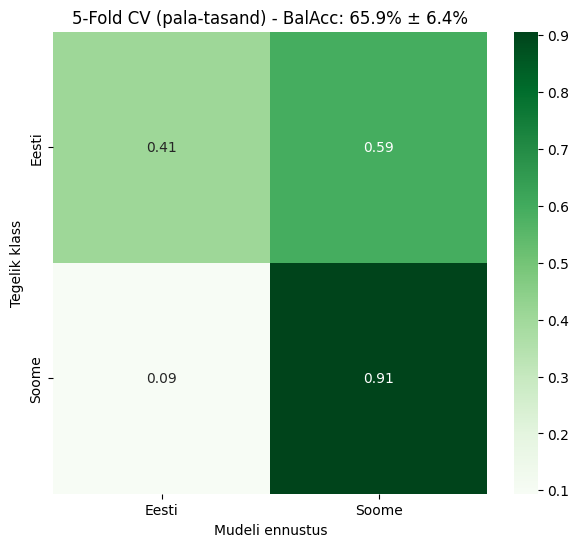


Tulemused salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/cv_results.csv


In [4]:
# --- 4. STRATIFIED K-FOLD CV (PALA-TASANDIL) ---
import random
SEED = 43
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score,
                              classification_report, balanced_accuracy_score)
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kasutan: {device}")

N_FOLDS = 5
EPOCHS_FROZEN = 12
EPOCHS_FT = 3
PATIENCE = 3

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)


def evaluate_segments(model, loader):
    model.eval()
    preds, lbls = [], []
    with torch.no_grad():
        for inp, mask, lab, _ in loader:
            out = model(inp.to(device), mask.to(device))
            preds.extend(torch.argmax(out, 1).cpu().numpy())
            lbls.extend(lab.numpy())
    return preds, lbls


def evaluate_songs(model, loader):
    model.eval()
    song_logits = defaultdict(list)
    song_lbls = {}
    with torch.no_grad():
        for inp, mask, lab, sid in loader:
            out = model(inp.to(device), mask.to(device))
            for i, s in enumerate(sid):
                s = int(s)
                song_logits[s].append(out[i].cpu().numpy())
                song_lbls[s] = int(lab[i])
    preds, lbls = [], []
    for s, lst in song_logits.items():
        preds.append(int(np.argmax(np.mean(lst, axis=0))))
        lbls.append(song_lbls[s])
    return preds, lbls


# Tulemuste kogumine
fold_results = []
all_preds_aggregate = []
all_labels_aggregate = []

# Salvestame algse mudeli kaalud, et iga fold algaks puhtalt
import copy
initial_state = copy.deepcopy(midibert_base.state_dict())


for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1} / {N_FOLDS}")
    print('='*70)

    # Veel jagame trainval -> train ja valid (stratified, 85/15)
    trainval_labels = all_labels[trainval_idx]
    inner_skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42 + fold_idx)
    inner_split = next(inner_skf.split(trainval_idx, trainval_labels))
    train_idx_local, valid_idx_local = inner_split
    train_idx = trainval_idx[train_idx_local]
    valid_idx = trainval_idx[valid_idx_local]

    train_paths_f = [all_paths[i] for i in train_idx]
    train_labels_f = all_labels[train_idx]
    train_sids_f = all_song_ids[train_idx]

    valid_paths_f = [all_paths[i] for i in valid_idx]
    valid_labels_f = all_labels[valid_idx]
    valid_sids_f = all_song_ids[valid_idx]

    test_paths_f = [all_paths[i] for i in test_idx]
    test_labels_f = all_labels[test_idx]
    test_sids_f = all_song_ids[test_idx]

    print(f"Train palu: {len(train_paths_f)} "
          f"(Eesti: {(train_labels_f == 0).sum()}, Soome: {(train_labels_f == 1).sum()})")
    print(f"Valid palu: {len(valid_paths_f)} "
          f"(Eesti: {(valid_labels_f == 0).sum()}, Soome: {(valid_labels_f == 1).sum()})")
    print(f"Test palu:  {len(test_paths_f)} "
          f"(Eesti: {(test_labels_f == 0).sum()}, Soome: {(test_labels_f == 1).sum()})")

    # Tokeniseerime
    print("\nTokeniseerin...")
    train_data_f = build_segments(train_paths_f, train_labels_f, train_sids_f, augment=True)
    valid_data_f = build_segments(valid_paths_f, valid_labels_f, valid_sids_f, augment=False)
    test_data_f = build_segments(test_paths_f, test_labels_f, test_sids_f, augment=False)
    print(f"Train seg: {len(train_data_f)}, Valid seg: {len(valid_data_f)}, Test seg: {len(test_data_f)}")

    # WeightedRandomSampler treeninguks
    seg_labels = [s[1] for s in train_data_f]
    n_e_seg = seg_labels.count(0)
    n_s_seg = seg_labels.count(1)
    sample_weights = [1.0/n_e_seg if l == 0 else 1.0/n_s_seg for l in seg_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(seg_labels), replacement=True)

    train_loader = DataLoader(FolkDataset(train_data_f), batch_size=8, sampler=sampler)
    valid_loader = DataLoader(FolkDataset(valid_data_f), batch_size=8, shuffle=False)
    test_loader = DataLoader(FolkDataset(test_data_f), batch_size=8, shuffle=False)

    # --- Värske mudel sellele fold'ile ---
    midibert_base.load_state_dict(initial_state)  # taasta originaal-kaalud
    classifier_model = FolkClassifier(midibert_base, len(target_labels)).to(device)

    # Faas A: külmutatud BERT
    for p in classifier_model.midibert.parameters():
        p.requires_grad = False
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, classifier_model.parameters()),
        lr=1e-3, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()  # ilma class weights, sampler tasakaalustab

    best_balacc = 0
    patience_counter = 0
    print(f"\n--- Külmutatud baas ({EPOCHS_FROZEN} epohhi max) ---")
    for epoch in range(EPOCHS_FROZEN):
        classifier_model.train()
        for inp, mask, lab, _ in train_loader:
            inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
            optimizer.zero_grad()
            out = classifier_model(inp, mask)
            loss = criterion(out, lab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(classifier_model.parameters(), 1.0)
            optimizer.step()

        vp, vl = evaluate_segments(classifier_model, valid_loader)
        v_balacc = balanced_accuracy_score(vl, vp)
        if (epoch + 1) % 2 == 0:
            print(f"  Ep {epoch+1}: valid_BalAcc={v_balacc:.3f}")

        if v_balacc > best_balacc:
            best_balacc = v_balacc
            patience_counter = 0
            torch.save(classifier_model.state_dict(), f"best_fold{fold_idx}_frozen.pt")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Frozen early stop ep{epoch+1}, best valid BalAcc={best_balacc:.3f}")
                break

    classifier_model.load_state_dict(torch.load(f"best_fold{fold_idx}_frozen.pt"))

    # Faas B: fine-tune VIIMASE 1 BERT-i kihiga (konservatiivne)
    print(f"\n--- Fine-tune (1 kiht, lr 5e-6) ---")
    for p in classifier_model.parameters():
        p.requires_grad = False
    for p in classifier_model.classifier.parameters():
        p.requires_grad = True
    n_layers = len(classifier_model.midibert.bert.encoder.layer)
    for i in range(n_layers - 1, n_layers):  # ainult viimane kiht
        for p in classifier_model.midibert.bert.encoder.layer[i].parameters():
            p.requires_grad = True

    bert_params = [p for n, p in classifier_model.named_parameters()
                   if 'midibert' in n and p.requires_grad]
    clf_params = [p for n, p in classifier_model.named_parameters()
                  if 'classifier' in n and p.requires_grad]
    optimizer_ft = torch.optim.AdamW([
        {'params': bert_params, 'lr': 5e-6},
        {'params': clf_params, 'lr': 5e-5}
    ], weight_decay=0.05)

    best_ft_balacc = best_balacc
    patience_counter = 0
    for epoch in range(EPOCHS_FT):
        classifier_model.train()
        for inp, mask, lab, _ in train_loader:
            inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
            optimizer_ft.zero_grad()
            out = classifier_model(inp, mask)
            loss = criterion(out, lab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(classifier_model.parameters(), 1.0)
            optimizer_ft.step()

        vp, vl = evaluate_segments(classifier_model, valid_loader)
        v_balacc = balanced_accuracy_score(vl, vp)
        print(f"  FT Ep {epoch+1}: valid_BalAcc={v_balacc:.3f}")

        if v_balacc > best_ft_balacc:
            best_ft_balacc = v_balacc
            patience_counter = 0
            torch.save(classifier_model.state_dict(), f"best_fold{fold_idx}_ft.pt")
        else:
            patience_counter += 1
            if patience_counter >= 1:
                break

    if os.path.exists(f"best_fold{fold_idx}_ft.pt"):
        classifier_model.load_state_dict(torch.load(f"best_fold{fold_idx}_ft.pt"))

    # --- HINDAMINE TEST FOLD'i peal ---
    print(f"\n--- Test fold {fold_idx + 1} ---")
    sp, sl = evaluate_songs(classifier_model, test_loader)
    fold_acc = accuracy_score(sl, sp)
    fold_balacc = balanced_accuracy_score(sl, sp)
    fold_f1 = f1_score(sl, sp, average='macro')
    e_recall = sum(1 for p, l in zip(sp, sl) if l == 0 and p == 0) / max(1, sl.count(0))
    s_recall = sum(1 for p, l in zip(sp, sl) if l == 1 and p == 1) / max(1, sl.count(1))

    print(f"  Acc: {fold_acc:.3f} | BalAcc: {fold_balacc:.3f} | F1: {fold_f1:.3f}")
    print(f"  Eesti recall: {e_recall:.3f} | Soome recall: {s_recall:.3f}")

    fold_results.append({
        'fold': fold_idx + 1,
        'acc': fold_acc,
        'balacc': fold_balacc,
        'f1': fold_f1,
        'eesti_recall': e_recall,
        'soome_recall': s_recall,
        'n_eesti_test': sl.count(0),
        'n_soome_test': sl.count(1)
    })
    all_preds_aggregate.extend(sp)
    all_labels_aggregate.extend(sl)


# === KOKKUVÕTE 5 FOLD'i ÜLE ===
print("\n" + "="*70)
print("K-FOLD CV LÕPLIKUD TULEMUSED")
print("="*70)

import pandas as pd
df = pd.DataFrame(fold_results)
print("\n--- Iga fold'i tulemus ---")
print(df.to_string(index=False))

print("\n--- KESKMINE ± HÄLVE ---")
print(f"Accuracy:        {df['acc'].mean():.3f} ± {df['acc'].std():.3f}")
print(f"Balanced Acc:    {df['balacc'].mean():.3f} ± {df['balacc'].std():.3f}")
print(f"Macro F1:        {df['f1'].mean():.3f} ± {df['f1'].std():.3f}")
print(f"Eesti recall:    {df['eesti_recall'].mean():.3f} ± {df['eesti_recall'].std():.3f}")
print(f"Soome recall:    {df['soome_recall'].mean():.3f} ± {df['soome_recall'].std():.3f}")

# Aggregaaditud confusion matrix (kogu CV peal)
print("\n--- KOGU CV PEAL AGGREGEERITUD ---")
print(classification_report(all_labels_aggregate, all_preds_aggregate,
                              target_names=target_labels, digits=3))

cm = confusion_matrix(all_labels_aggregate, all_preds_aggregate)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(7, 6))
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=target_labels, yticklabels=target_labels)
plt.ylabel('Tegelik klass'); plt.xlabel('Mudeli ennustus')
plt.title(f'5-Fold CV (pala-tasand) - BalAcc: {df["balacc"].mean()*100:.1f}% ± {df["balacc"].std()*100:.1f}%')
plt.savefig('/content/drive/MyDrive/LÕPUTÖÖ/cv_confusion_matrix.png', dpi=150, bbox_inches='tight')
# Salvesta parima fold'i mudel
best_fold_idx = df['balacc'].idxmax()
best_fold_num = df.loc[best_fold_idx, 'fold']
print(f"\nParim fold: {int(best_fold_num)} (BalAcc={df.loc[best_fold_idx, 'balacc']:.3f})")

# Kopeerime Drive'i
import shutil
for suffix in ['ft', 'frozen']:
    src = f"best_fold{int(best_fold_num)-1}_{suffix}.pt"
    if os.path.exists(src):
        dst = f"/content/drive/MyDrive/LÕPUTÖÖ/best_fold{int(best_fold_num)}_{suffix}.pt"
        shutil.copy(src, dst)
        print(f"Salvestatud: {dst}")
plt.show()

# Salvesta tulemused csv-na
df.to_csv('/content/drive/MyDrive/LÕPUTÖÖ/cv_results.csv', index=False)
print("\nTulemused salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/cv_results.csv")

In [5]:
# --- LÕPLIK MUDEL KOGU ANDMESTIKUL (attention rollout jaoks) ---
print("Treenin lõpliku mudeli kogu andmestikul...")

all_segments = build_segments(all_paths, all_labels, all_song_ids, augment=True)
print(f"Segmente kokku: {len(all_segments)}")

seg_labels = [s[1] for s in all_segments]
n_e = seg_labels.count(0); n_s = seg_labels.count(1)
sw = [1.0/n_e if l == 0 else 1.0/n_s for l in seg_labels]
sampler_full = WeightedRandomSampler(sw, num_samples=len(sw), replacement=True)
full_loader = DataLoader(FolkDataset(all_segments), batch_size=8, sampler=sampler_full)

# Värske mudel
midibert_base.load_state_dict(initial_state)
final_model = FolkClassifier(midibert_base, len(target_labels)).to(device)

# Külmutatud faas
for p in final_model.midibert.parameters():
    p.requires_grad = False
opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, final_model.parameters()),
    lr=1e-3, weight_decay=0.01)
crit = nn.CrossEntropyLoss()

for epoch in range(8):
    final_model.train()
    total_loss = 0
    for inp, mask, lab, _ in full_loader:
        inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
        opt.zero_grad()
        loss = crit(final_model(inp, mask), lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        opt.step()
        total_loss += loss.item()
    print(f"  Ep {epoch+1}/8, avg loss: {total_loss/len(full_loader):.4f}")

# Fine-tune viimane kiht
for p in final_model.parameters():
    p.requires_grad = False
for p in final_model.classifier.parameters():
    p.requires_grad = True
n_layers = len(final_model.midibert.bert.encoder.layer)
for p in final_model.midibert.bert.encoder.layer[n_layers-1].parameters():
    p.requires_grad = True

bert_p = [p for n, p in final_model.named_parameters() if 'midibert' in n and p.requires_grad]
clf_p = [p for n, p in final_model.named_parameters() if 'classifier' in n and p.requires_grad]
opt_ft = torch.optim.AdamW([
    {'params': bert_p, 'lr': 5e-6},
    {'params': clf_p, 'lr': 5e-5}
], weight_decay=0.05)

for epoch in range(3):
    final_model.train()
    total_loss = 0
    for inp, mask, lab, _ in full_loader:
        inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
        opt_ft.zero_grad()
        loss = crit(final_model(inp, mask), lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        opt_ft.step()
        total_loss += loss.item()
    print(f"  FT Ep {epoch+1}/3, avg loss: {total_loss/len(full_loader):.4f}")

save_path = "/content/drive/MyDrive/LÕPUTÖÖ/final_folk_model.pt"
torch.save(final_model.state_dict(), save_path)
print(f"\nLõplik mudel salvestatud: {save_path}")

Treenin lõpliku mudeli kogu andmestikul...


100%|██████████| 1/1 [00:00<00:00, 187.77it/s]

100%|██████████| 1/1 [00:00<00:00, 243.04it/s]

100%|██████████| 1/1 [00:00<00:00, 230.00it/s]

100%|██████████| 1/1 [00:00<00:00, 217.51it/s]

100%|██████████| 1/1 [00:00<00:00, 241.72it/s]

100%|██████████| 1/1 [00:00<00:00, 152.88it/s]

100%|██████████| 1/1 [00:00<00:00, 279.04it/s]

100%|██████████| 1/1 [00:00<00:00, 312.73it/s]

100%|██████████| 1/1 [00:00<00:00, 231.69it/s]

100%|██████████| 1/1 [00:00<00:00, 250.45it/s]

100%|██████████| 1/1 [00:00<00:00, 118.61it/s]

100%|██████████| 1/1 [00:00<00:00, 113.85it/s]

100%|██████████| 1/1 [00:00<00:00, 120.38it/s]

100%|██████████| 1/1 [00:00<00:00, 110.84it/s]

100%|██████████| 1/1 [00:00<00:00, 120.33it/s]

100%|██████████| 1/1 [00:00<00:00, 88.33it/s]

100%|██████████| 1/1 [00:00<00:00, 90.60it/s]

100%|██████████| 1/1 [00:00<00:00, 98.83it/s]

100%|██████████| 1/1 [00:00<00:00, 96.24it/s]

100%|██████████| 1/1 [00:00<00:00, 104.69it/s]

100%|██████████| 1/1 [00:00<00:00, 96.32it/s

Segmente kokku: 1127
  Ep 1/8, avg loss: 0.4960
  Ep 2/8, avg loss: 0.4307
  Ep 3/8, avg loss: 0.3312
  Ep 4/8, avg loss: 0.3742
  Ep 5/8, avg loss: 0.3405
  Ep 6/8, avg loss: 0.3364
  Ep 7/8, avg loss: 0.3670
  Ep 8/8, avg loss: 0.3186
  FT Ep 1/3, avg loss: 0.3355
  FT Ep 2/3, avg loss: 0.3474
  FT Ep 3/3, avg loss: 0.3049

Lõplik mudel salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/final_folk_model.pt


In [6]:
# --- Kontrolli: kas mudel õppis? (treeningu-täpsus, mitte aus hinnang) ---
print("\n=== TREENINGU-TÄPSUS (optimistlik, ainult kontrolliks) ===")
all_loader = DataLoader(FolkDataset(all_segments), batch_size=8, shuffle=False)

final_model.eval()
song_logits = defaultdict(list)
song_lbls = {}
with torch.no_grad():
    for inp, mask, lab, sid in all_loader:
        out = final_model(inp.to(device), mask.to(device))
        for i, s in enumerate(sid):
            s = int(s)
            song_logits[s].append(out[i].cpu().numpy())
            song_lbls[s] = int(lab[i])

preds, lbls = [], []
for s, lst in song_logits.items():
    preds.append(int(np.argmax(np.mean(lst, axis=0))))
    lbls.append(song_lbls[s])

from sklearn.metrics import balanced_accuracy_score, classification_report
print(f"Pala-tasand BalAcc (train): {balanced_accuracy_score(lbls, preds):.3f}")
print(classification_report(lbls, preds, target_names=target_labels, digits=3))

# Mitu Eesti ja Soome pala sai õigesti?
e_total = sum(1 for l in lbls if l == 0)
e_correct = sum(1 for p, l in zip(preds, lbls) if l == 0 and p == 0)
s_total = sum(1 for l in lbls if l == 1)
s_correct = sum(1 for p, l in zip(preds, lbls) if l == 1 and p == 1)
print(f"Eesti: {e_correct}/{e_total} õigesti ({e_correct/e_total*100:.0f}%)")
print(f"Soome: {s_correct}/{s_total} õigesti ({s_correct/s_total*100:.0f}%)")


=== TREENINGU-TÄPSUS (optimistlik, ainult kontrolliks) ===
Pala-tasand BalAcc (train): 0.968
              precision    recall  f1-score   support

       Eesti      0.635     1.000     0.777        54
       Soome      1.000     0.935     0.967       479

    accuracy                          0.942       533
   macro avg      0.818     0.968     0.872       533
weighted avg      0.963     0.942     0.947       533

Eesti: 54/54 õigesti (100%)
Soome: 448/479 õigesti (94%)


In [ ]:
# --- 8. BAR-TOKEN ABLATSIOON: K-FOLD CV ---
# Sama eksperiment nagu lahter 4, aga mudel ei näe Bar-tokeneid (mask_bar_tokens=True).
# Kui BalAcc langeb märgatavalt -> mudel kasutas Bar-infot.
# Kui jääb sarnaseks -> mudel õpib päris muusikalisi tunnuseid.

print("="*70)
print("BAR-TOKEN ABLATSIOON-EKSPERIMENT (K-FOLD CV)")
print("="*70)

skf_ab = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

ablation_results = []
ab_preds_all = []
ab_labels_all = []

for fold_idx, (trainval_idx, test_idx) in enumerate(skf_ab.split(all_paths, all_labels)):
    print(f"\n--- Ablation Fold {fold_idx + 1}/{N_FOLDS} ---")

    # Sama inner split nagu põhi-CV-s, et vältida andmeleket
    trainval_labels = all_labels[trainval_idx]
    inner_skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42 + fold_idx)
    inner_split = next(inner_skf.split(trainval_idx, trainval_labels))
    train_idx_local, valid_idx_local = inner_split
    train_idx = trainval_idx[train_idx_local]
    valid_idx = trainval_idx[valid_idx_local]

    train_paths_f = [all_paths[i] for i in train_idx]
    train_labels_f = all_labels[train_idx]
    train_sids_f = all_song_ids[train_idx]
    valid_paths_f = [all_paths[i] for i in valid_idx]
    valid_labels_f = all_labels[valid_idx]
    valid_sids_f = all_song_ids[valid_idx]
    test_paths_f = [all_paths[i] for i in test_idx]
    test_labels_f = all_labels[test_idx]
    test_sids_f = all_song_ids[test_idx]

    # Tokeniseerime
    train_data_f = build_segments(train_paths_f, train_labels_f, train_sids_f, augment=True)
    valid_data_f = build_segments(valid_paths_f, valid_labels_f, valid_sids_f, augment=False)
    test_data_f = build_segments(test_paths_f, test_labels_f, test_sids_f, augment=False)

    seg_labels = [s[1] for s in train_data_f]
    n_e = seg_labels.count(0); n_s = seg_labels.count(1)
    sample_weights = [1.0/n_e if l == 0 else 1.0/n_s for l in seg_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(seg_labels), replacement=True)

    train_loader = DataLoader(FolkDataset(train_data_f), batch_size=8, sampler=sampler)
    valid_loader = DataLoader(FolkDataset(valid_data_f), batch_size=8, shuffle=False)
    test_loader = DataLoader(FolkDataset(test_data_f), batch_size=8, shuffle=False)

    # MUUTUS: mask_bar_tokens=True
    midibert_base.load_state_dict(initial_state)
    ablation_model = FolkClassifier(midibert_base, len(target_labels),
                                     mask_bar_tokens=True).to(device)

    for p in ablation_model.midibert.parameters():
        p.requires_grad = False
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, ablation_model.parameters()),
        lr=1e-3, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    # Frozen treening
    best_balacc = 0
    patience_counter = 0
    for epoch in range(EPOCHS_FROZEN):
        ablation_model.train()
        for inp, mask, lab, _ in train_loader:
            inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
            optimizer.zero_grad()
            out = ablation_model(inp, mask)
            loss = criterion(out, lab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ablation_model.parameters(), 1.0)
            optimizer.step()

        vp, vl = evaluate_segments(ablation_model, valid_loader)
        v_balacc = balanced_accuracy_score(vl, vp)
        if v_balacc > best_balacc:
            best_balacc = v_balacc
            patience_counter = 0
            torch.save(ablation_model.state_dict(), f"ab_fold{fold_idx}_frozen.pt")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    ablation_model.load_state_dict(torch.load(f"ab_fold{fold_idx}_frozen.pt"))

    # Fine-tune (1 kiht)
    for p in ablation_model.parameters():
        p.requires_grad = False
    for p in ablation_model.classifier.parameters():
        p.requires_grad = True
    n_layers = len(ablation_model.midibert.bert.encoder.layer)
    for i in range(n_layers - 1, n_layers):
        for p in ablation_model.midibert.bert.encoder.layer[i].parameters():
            p.requires_grad = True

    bert_params = [p for n, p in ablation_model.named_parameters()
                   if 'midibert' in n and p.requires_grad]
    clf_params = [p for n, p in ablation_model.named_parameters()
                  if 'classifier' in n and p.requires_grad]
    optimizer_ft = torch.optim.AdamW([
        {'params': bert_params, 'lr': 5e-6},
        {'params': clf_params, 'lr': 5e-5}
    ], weight_decay=0.05)

    best_ft_balacc = best_balacc
    patience_counter = 0
    for epoch in range(EPOCHS_FT):
        ablation_model.train()
        for inp, mask, lab, _ in train_loader:
            inp, mask, lab = inp.to(device), mask.to(device), lab.to(device)
            optimizer_ft.zero_grad()
            out = ablation_model(inp, mask)
            loss = criterion(out, lab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ablation_model.parameters(), 1.0)
            optimizer_ft.step()

        vp, vl = evaluate_segments(ablation_model, valid_loader)
        v_balacc = balanced_accuracy_score(vl, vp)
        if v_balacc > best_ft_balacc:
            best_ft_balacc = v_balacc
            patience_counter = 0
            torch.save(ablation_model.state_dict(), f"ab_fold{fold_idx}_ft.pt")
        else:
            patience_counter += 1
            if patience_counter >= 1:
                break

    if os.path.exists(f"ab_fold{fold_idx}_ft.pt"):
        ablation_model.load_state_dict(torch.load(f"ab_fold{fold_idx}_ft.pt"))

    # Hindamine
    sp, sl = evaluate_songs(ablation_model, test_loader)
    fold_acc = accuracy_score(sl, sp)
    fold_balacc = balanced_accuracy_score(sl, sp)
    fold_f1 = f1_score(sl, sp, average='macro')
    e_recall = sum(1 for p, l in zip(sp, sl) if l == 0 and p == 0) / max(1, sl.count(0))
    s_recall = sum(1 for p, l in zip(sp, sl) if l == 1 and p == 1) / max(1, sl.count(1))

    print(f"  Acc={fold_acc:.3f} BalAcc={fold_balacc:.3f} "
          f"E_recall={e_recall:.3f} S_recall={s_recall:.3f}")

    ablation_results.append({
        'fold': fold_idx + 1, 'acc': fold_acc, 'balacc': fold_balacc, 'f1': fold_f1,
        'eesti_recall': e_recall, 'soome_recall': s_recall
    })
    ab_preds_all.extend(sp)
    ab_labels_all.extend(sl)


# === VÕRDLUS ===
print("\n" + "="*70)
print("ABLATSIOONI KOKKUVÕTE")
print("="*70)

df_ab = pd.DataFrame(ablation_results)
print("\n--- Iga fold ---")
print(df_ab.to_string(index=False))

print("\n--- KESKMINE ± HÄLVE (ilma Bar-tokenita) ---")
print(f"Accuracy:        {df_ab['acc'].mean():.3f} ± {df_ab['acc'].std():.3f}")
print(f"Balanced Acc:    {df_ab['balacc'].mean():.3f} ± {df_ab['balacc'].std():.3f}")
print(f"Macro F1:        {df_ab['f1'].mean():.3f} ± {df_ab['f1'].std():.3f}")
print(f"Eesti recall:    {df_ab['eesti_recall'].mean():.3f} ± {df_ab['eesti_recall'].std():.3f}")
print(f"Soome recall:    {df_ab['soome_recall'].mean():.3f} ± {df_ab['soome_recall'].std():.3f}")

# Võrdle põhitulemustega
print("\n" + "="*70)
print("PÕHIMUDEL vs ABLATSIOON")
print("="*70)
print(f"                    Põhi (Bar-iga)    Ablat (ilma Bar)    VAHE")
print(f"BalAcc:             {df['balacc'].mean():.3f} ± {df['balacc'].std():.3f}   "
      f"{df_ab['balacc'].mean():.3f} ± {df_ab['balacc'].std():.3f}   "
      f"{(df['balacc'].mean() - df_ab['balacc'].mean())*100:+.1f}%")
print(f"Eesti recall:       {df['eesti_recall'].mean():.3f}            "
      f"{df_ab['eesti_recall'].mean():.3f}            "
      f"{(df['eesti_recall'].mean() - df_ab['eesti_recall'].mean())*100:+.1f}%")
print(f"Soome recall:       {df['soome_recall'].mean():.3f}            "
      f"{df_ab['soome_recall'].mean():.3f}            "
      f"{(df['soome_recall'].mean() - df_ab['soome_recall'].mean())*100:+.1f}%")

print("\n--- TÕLGENDUS ---")
diff = df['balacc'].mean() - df_ab['balacc'].mean()
if diff < 0.03:
    print("✓ Vahe väike (<3%): mudel õpib peamiselt MUUSIKALIST sisu, mitte Bar-struktuuri.")
    print("  See on tugev tulemus lõputöö metoodika osasse.")
elif diff < 0.10:
    print("~ Mõõdukas vahe (3-10%): Bar-tokenid annavad mingit lisainfot,")
    print("  aga mudel sõltub neist mõõdukalt. Tasakaal muusikalise ja struktuurse vahel.")
else:
    print("⚠ Suur vahe (>10%): mudel sõltub tugevalt Bar-tokenitest.")
    print("  See võib viidata, et osa eristuvõimest tuleb struktuurist, mitte muusikast.")

# Salvesta
df_ab.to_csv('/content/drive/MyDrive/LÕPUTÖÖ/ablation_results.csv', index=False)
print("\nTulemused salvestatud: /content/drive/MyDrive/LÕPUTÖÖ/ablation_results.csv")

BAR-TOKEN ABLATSIOON-EKSPERIMENT (K-FOLD CV)

--- Ablation Fold 1/5 ---


100%|██████████| 1/1 [00:00<00:00, 28.76it/s]

100%|██████████| 1/1 [00:00<00:00, 100.47it/s]

100%|██████████| 1/1 [00:00<00:00, 78.44it/s]

100%|██████████| 1/1 [00:00<00:00, 105.98it/s]

100%|██████████| 1/1 [00:00<00:00, 101.17it/s]

100%|██████████| 1/1 [00:00<00:00, 53.16it/s]

100%|██████████| 1/1 [00:00<00:00, 110.54it/s]

100%|██████████| 1/1 [00:00<00:00, 127.64it/s]

100%|██████████| 1/1 [00:00<00:00, 104.94it/s]

100%|██████████| 1/1 [00:00<00:00, 128.98it/s]

100%|██████████| 1/1 [00:00<00:00, 151.17it/s]

100%|██████████| 1/1 [00:00<00:00, 123.60it/s]

100%|██████████| 1/1 [00:00<00:00, 120.16it/s]

100%|██████████| 1/1 [00:00<00:00, 121.42it/s]

100%|██████████| 1/1 [00:00<00:00, 126.85it/s]

100%|██████████| 1/1 [00:00<00:00, 54.48it/s]

100%|██████████| 1/1 [00:00<00:00, 113.88it/s]

100%|██████████| 1/1 [00:00<00:00, 145.91it/s]

100%|██████████| 1/1 [00:00<00:00, 139.29it/s]

100%|██████████| 1/1 [00:00<00:00, 152.97it/s]

100%|██████████| 1/1 [00:00<00:00, 100.03it/

  Acc=0.728 BalAcc=0.626 E_recall=0.500 S_recall=0.753

--- Ablation Fold 2/5 ---


100%|██████████| 1/1 [00:00<00:00, 246.51it/s]

100%|██████████| 1/1 [00:00<00:00, 217.12it/s]

100%|██████████| 1/1 [00:00<00:00, 292.16it/s]

100%|██████████| 1/1 [00:00<00:00, 122.53it/s]

100%|██████████| 1/1 [00:00<00:00, 135.63it/s]

100%|██████████| 1/1 [00:00<00:00, 78.21it/s]

100%|██████████| 1/1 [00:00<00:00, 175.01it/s]

100%|██████████| 1/1 [00:00<00:00, 191.07it/s]

100%|██████████| 1/1 [00:00<00:00, 245.15it/s]

100%|██████████| 1/1 [00:00<00:00, 130.06it/s]

100%|██████████| 1/1 [00:00<00:00, 92.05it/s]

100%|██████████| 1/1 [00:00<00:00, 97.23it/s]

100%|██████████| 1/1 [00:00<00:00, 118.57it/s]

100%|██████████| 1/1 [00:00<00:00, 101.41it/s]

100%|██████████| 1/1 [00:00<00:00, 121.08it/s]

100%|██████████| 1/1 [00:00<00:00, 74.12it/s]

100%|██████████| 1/1 [00:00<00:00, 96.24it/s]

100%|██████████| 1/1 [00:00<00:00, 65.38it/s]

100%|██████████| 1/1 [00:00<00:00, 58.47it/s]

100%|██████████| 1/1 [00:00<00:00, 90.07it/s]

100%|██████████| 1/1 [00:00<00:00, 111.57it/s]



  Acc=0.885 BalAcc=0.583 E_recall=0.200 S_recall=0.965

--- Ablation Fold 3/5 ---


...

  Acc=0.898 BalAcc=0.621 E_recall=0.273 S_recall=0.969

--- Ablation Fold 4/5 ---


100%|██████████| 1/1 [00:00<00:00, 149.92it/s]

100%|██████████| 1/1 [00:00<00:00, 169.95it/s]

100%|██████████| 1/1 [00:00<00:00, 105.16it/s]

100%|██████████| 1/1 [00:00<00:00, 95.99it/s]

100%|██████████| 1/1 [00:00<00:00, 98.00it/s]

100%|██████████| 1/1 [00:00<00:00, 69.81it/s]

100%|██████████| 1/1 [00:00<00:00, 84.72it/s]

100%|██████████| 1/1 [00:00<00:00, 104.43it/s]

100%|██████████| 1/1 [00:00<00:00, 96.36it/s]

100%|██████████| 1/1 [00:00<00:00, 96.43it/s]

100%|██████████| 1/1 [00:00<00:00, 102.56it/s]

100%|██████████| 1/1 [00:00<00:00, 123.84it/s]

100%|██████████| 1/1 [00:00<00:00, 111.50it/s]

100%|██████████| 1/1 [00:00<00:00, 107.41it/s]

100%|██████████| 1/1 [00:00<00:00, 116.46it/s]

100%|██████████| 1/1 [00:00<00:00, 83.27it/s]

100%|██████████| 1/1 [00:00<00:00, 115.21it/s]

100%|██████████| 1/1 [00:00<00:00, 143.11it/s]

100%|██████████| 1/1 [00:00<00:00, 133.59it/s]

100%|██████████| 1/1 [00:00<00:00, 128.69it/s]

100%|██████████| 1/1 [00:00<00:00, 45.53it/s]



  Acc=0.705 BalAcc=0.675 E_recall=0.636 S_recall=0.713

--- Ablation Fold 5/5 ---


100%|██████████| 1/1 [00:00<00:00, 260.63it/s]

100%|██████████| 1/1 [00:00<00:00, 490.56it/s]

100%|██████████| 1/1 [00:00<00:00, 316.86it/s]

100%|██████████| 1/1 [00:00<00:00, 168.27it/s]

100%|██████████| 1/1 [00:00<00:00, 219.77it/s]

100%|██████████| 1/1 [00:00<00:00, 149.26it/s]

100%|██████████| 1/1 [00:00<00:00, 232.38it/s]

100%|██████████| 1/1 [00:00<00:00, 282.16it/s]

100%|██████████| 1/1 [00:00<00:00, 281.93it/s]

100%|██████████| 1/1 [00:00<00:00, 274.12it/s]

100%|██████████| 1/1 [00:00<00:00, 118.55it/s]

100%|██████████| 1/1 [00:00<00:00, 111.51it/s]

100%|██████████| 1/1 [00:00<00:00, 114.75it/s]

100%|██████████| 1/1 [00:00<00:00, 113.01it/s]

100%|██████████| 1/1 [00:00<00:00, 116.65it/s]

100%|██████████| 1/1 [00:00<00:00, 86.86it/s]

100%|██████████| 1/1 [00:00<00:00, 111.51it/s]

100%|██████████| 1/1 [00:00<00:00, 92.26it/s]

100%|██████████| 1/1 [00:00<00:00, 114.54it/s]

100%|██████████| 1/1 [00:00<00:00, 121.67it/s]

100%|██████████| 1/1 [00:00<00:00, 136.94i

  Acc=0.798 BalAcc=0.593 E_recall=0.333 S_recall=0.853

ABLATSIOONI KOKKUVÕTE

--- Iga fold ---
 fold      acc   balacc       f1  eesti_recall  soome_recall
    1 0.728155 0.626344 0.548246      0.500000      0.752688
    2 0.885417 0.582558 0.602260      0.200000      0.965116
    3 0.898148 0.620900 0.648832      0.272727      0.969072
    4 0.705357 0.674617 0.555716      0.636364      0.712871
    5 0.798246 0.593137 0.570657      0.333333      0.852941

--- KESKMINE ± HÄLVE (ilma Bar-tokenita) ---
Accuracy:        0.803 ± 0.088
Balanced Acc:    0.620 ± 0.036
Macro F1:        0.585 ± 0.041
Eesti recall:    0.388 ± 0.177
Soome recall:    0.851 ± 0.118

PÕHIMUDEL vs ABLATSIOON
                    Põhi (Bar-iga)    Ablat (ilma Bar)    VAHE
BalAcc:             0.719 ± 0.051   0.620 ± 0.036   +10.0%
Eesti recall:       0.505            0.388            +11.6%
Soome recall:       0.933            0.851            +8.3%

--- TÕLGENDUS ---
~ Mõõdukas vahe (3-10%): Bar-tokenid annavad mingi